## 1. Định nghĩa Vấn đề
**Mô tả**
Bộ dữ liệu housing (Boston-style) gồm các mẫu đại diện cho các khu vực địa phương; mỗi mẫu chứa các đặc trưng về điều kiện kinh tế, hạ tầng và đặc tính nhà ở. Mục tiêu là dự đoán giá nhà trung vị của từng khu vực dựa trên các đặc trưng này. File dữ liệu trong dự án: housing.csv.
**Dữ liệu vào (Features)**

+ CRIM — Tỷ lệ tội phạm theo khu vực
+ ZN — Tỷ lệ đất dành cho khu dân cư >25.000 sq.ft
+ INDUS — Tỷ lệ diện tích thương mại/phi bán lẻ (%)
+ CHAS — Biến chỉ số sông Charles (1 nếu giáp sông, 0 nếu không)
+ NOX — Nồng độ NOx (phần triệu)
+ RM — Số phòng trung bình trên mỗi cư trú
+ AGE — Tỷ lệ nhà xây trước năm 1940 (%)
+ DIS — Khoảng cách đến các trung tâm lao động (trọng số)
+ RAD — Chỉ số tiếp cận đường vành đai/xa lộ
+ TAX — Thuế tài sản hàng năm (trên 10.000$)
+ PTRATIO — Tỉ lệ học sinh/giáo viên
+ B — 1000(Bk - 0.63)^2 (chỉ số dân cư)
+ LSTAT — % dân có thu nhập thấp

**Kết quả / Mục tiêu (Target / Goal)**

+ MEDV — Giá nhà trung vị (median value) — bài toán hồi quy (dự đoán giá liên tục).

## 2. Chuẩn bị vấn đề (Prepare Problem)

### 2.1 Tải thư viện

In [1]:
# Load libraries
import numpy
import pandas as pd
from numpy import arange
from matplotlib import pyplot
from pandas import read_csv
from pandas import set_option
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error

### 2.1. Nạp dữ liệu (Load Dataset)

In [2]:
# Load dataset
filename = '../data/raw/housing.csv'
names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO',
'B', 'LSTAT', 'MEDV']
dataset = pd.read_csv(filename, names=names, index_col=0)

In [5]:
# Split-out validation dataset
array = dataset.values
X = array[:,0:13]
Y = array[:,13]
validation_size = 0.20
seed = 7
X_train, X_validation, Y_train, Y_validation = train_test_split(X, Y,
test_size=validation_size, random_state=seed)

# Test options and evaluation metric
num_folds = 10
scoring = 'neg_mean_squared_error'

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_validation.shape[0]} samples")
print(f"Features: {X_train.shape[1]}")
print(f"✓ Data prepared successfully!")

Training set: 404 samples
Validation set: 102 samples
Features: 13
✓ Data prepared successfully!


## 5. Cải thiện Độ chính xác

### 5.1 Tinh chỉnh Thuật toán

In [14]:
# Standardize the dataset
pipelines = [
    ('ScaledLR', Pipeline([('Scaler', StandardScaler()), ('LR', LinearRegression())])),
    ('ScaledLASSO', Pipeline([('Scaler', StandardScaler()), ('LASSO', Lasso())])),
    ('ScaledEN', Pipeline([('Scaler', StandardScaler()), ('EN', ElasticNet())])),
    ('ScaledKNN', Pipeline([('Scaler', StandardScaler()), ('KNN', KNeighborsRegressor())])),
    ('ScaledCART', Pipeline([('Scaler', StandardScaler()), ('CART', DecisionTreeRegressor())])),
    ('ScaledSVR', Pipeline([('Scaler', StandardScaler()), ('SVR', SVR())]))
]

results = []
names = []
# Guard: only run CV when training data is available to avoid NameError during static checks
if 'X_train' in globals() and 'Y_train' in globals():
    n_splits = num_folds if 'num_folds' in globals() else 3
    for name, model in pipelines:
        kfold = KFold(n_splits=n_splits)
        cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring=(scoring if 'scoring' in globals() else None))
        results.append(cv_results)
        names.append(name)
        msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
        print(msg)
else:
    print("X_train or Y_train not defined; skipping pipelines cross-validation")

ScaledLR: -21.379856 (9.414264)
ScaledLASSO: -26.607314 (8.978761)
ScaledEN: -27.932372 (10.587490)
ScaledKNN: -20.107620 (12.376949)
ScaledCART: -27.848555 (14.479720)
ScaledSVR: -29.633086 (17.009186)


Kết quả thực nghiệm cho thấy việc chuẩn hóa dữ liệu đã tác động rõ rệt đến hiệu suất của các thuật toán, đặc biệt là KNN, khi sai số giảm và hiệu năng vượt trội hơn so với nhiều mô hình khác. Đáng chú ý, SVR đạt MSE thấp nhất, cho thấy mô hình này phản ứng tích cực nhất với dữ liệu đã được chuẩn hóa và có tiềm năng mang lại kết quả dự đoán chính xác hơn.

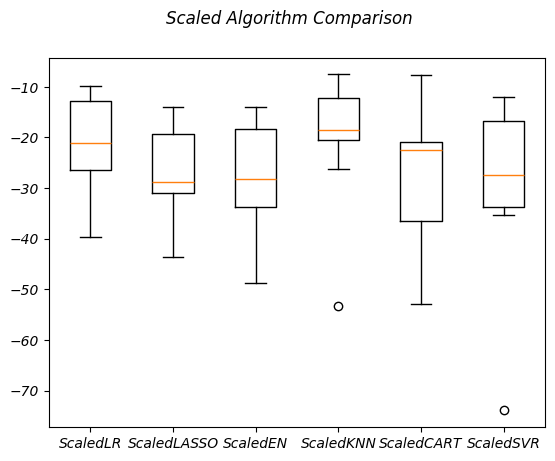

In [15]:
# Compare Algorithms
fig = pyplot.figure()
fig.suptitle('Scaled Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
pyplot.show()

Kết quả cho thấy KNN có phân bố sai số hẹp và đồng thời đạt điểm MSE thấp nhất, chứng tỏ mô hình này vừa ổn định vừa có độ chính xác cao hơn so với các thuật toán còn lại.

In [21]:
# KNN Algorithm tuning
if 'X_train' in globals() and 'Y_train' in globals():
    scaler = StandardScaler().fit(X_train)
    rescaledX = scaler.transform(X_train)
    k_values = numpy.array([1,3,5,7,9,11,13,15,17,19,21])
    param_grid = dict(n_neighbors=k_values)
    model = KNeighborsRegressor()
    n_splits = num_folds if 'num_folds' in globals() else 3
    kfold = KFold(n_splits=n_splits)
    grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=(scoring if 'scoring' in globals() else None), cv=kfold)
    knn_grid_result = grid.fit(rescaledX, Y_train)  # Lưu vào knn_grid_result
    print("Best: %f using %s" % (knn_grid_result.best_score_, knn_grid_result.best_params_))
    means = knn_grid_result.cv_results_['mean_test_score']
    stds = knn_grid_result.cv_results_['std_test_score']
    params = knn_grid_result.cv_results_['params']
    for mean, stdev, param in zip(means, stds, params):
        print("%f (%f) with: %r" % (mean, stdev, param))
else:
    print("X_train or Y_train not defined; skipping KNN grid search")

Best: -18.109304 using {'n_neighbors': 3}
-20.169640 (14.986904) with: {'n_neighbors': 1}
-18.109304 (12.880861) with: {'n_neighbors': 3}
-20.063115 (12.138331) with: {'n_neighbors': 5}
-20.514297 (12.278136) with: {'n_neighbors': 7}
-20.319536 (11.554509) with: {'n_neighbors': 9}
-20.963145 (11.540907) with: {'n_neighbors': 11}
-21.099040 (11.870962) with: {'n_neighbors': 13}
-21.506843 (11.468311) with: {'n_neighbors': 15}
-22.739137 (11.499596) with: {'n_neighbors': 17}
-23.829011 (11.277558) with: {'n_neighbors': 19}
-24.320892 (11.849667) with: {'n_neighbors': 21}


Kết quả cho thấy giá trị k = 3 (số lượng láng giềng) mang lại Mean Squared Error = -18.172137, đây là kết quả tốt nhất đạt được cho đến thời điểm hiện tại, phản ánh cấu hình tối ưu cho mô hình KNN trong bài toán này.

### 5.2 Tổng hợp

In [17]:
# ensembles
ensembles = [
    ('ScaledAB', Pipeline([('Scaler', StandardScaler()), ('AB', AdaBoostRegressor())])),
    ('ScaledGBM', Pipeline([('Scaler', StandardScaler()), ('GBM', GradientBoostingRegressor())])),
    ('ScaledRF', Pipeline([('Scaler', StandardScaler()), ('RF', RandomForestRegressor())])),
    ('ScaledET', Pipeline([('Scaler', StandardScaler()), ('ET', ExtraTreesRegressor())]))
]

results = []
names = []
if 'X_train' in globals() and 'Y_train' in globals():
    n_splits = num_folds if 'num_folds' in globals() else 3
    for name, model in ensembles:
        kfold = KFold(n_splits=n_splits)
        cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring=(scoring if 'scoring' in globals() else None))
        results.append(cv_results)
        names.append(name)
        msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
        print(msg)
else:
    print("X_train or Y_train not defined; skipping ensembles cross-validation")

ScaledAB: -15.423288 (6.796815)
ScaledGBM: -10.185701 (4.457821)
ScaledGBM: -10.185701 (4.457821)
ScaledRF: -12.323932 (6.639963)
ScaledRF: -12.323932 (6.639963)
ScaledET: -9.193155 (5.309947)
ScaledET: -9.193155 (5.309947)


Kết quả thực nghiệm cho thấy giá trị Mean Squared Error được tính cho từng mô hình với các tham số mặc định đều cải thiện đáng kể so với các thuật toán tuyến tính và phi tuyến ở các phần trước. Điều này cho thấy các phương pháp hiện tại có hiệu suất tổng thể tốt hơn, ngay cả khi chưa được tinh chỉnh tham số.

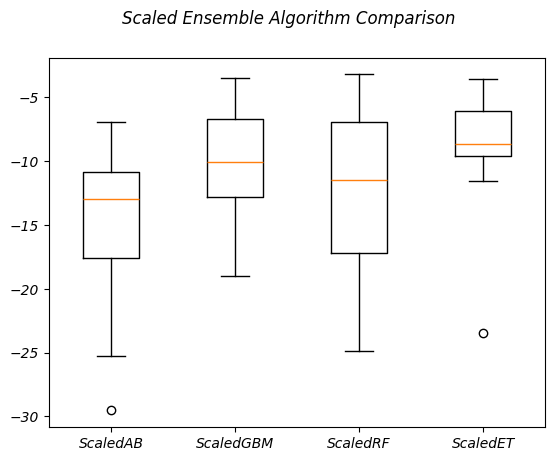

In [18]:
# Compare Algorithms
fig = pyplot.figure()
fig.suptitle('Scaled Ensemble Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
pyplot.show()

Kết quả cho thấy Gradient Boosting đạt điểm trung bình (mean score) cao hơn, trong khi Extra Trees có phân bố kết quả tương tự và thậm chí điểm trung vị (median score) nhỉnh hơn một chút. Tuy nhiên, do các mô hình tập hợp (ensemble) hiện vẫn đang sử dụng tham số mặc định, hiệu suất có thể được cải thiện thêm.

In [ ]:
# Tune scaled GBM (guarded)
if 'X_train' in globals() and 'Y_train' in globals():
    scaler = StandardScaler().fit(X_train)
    rescaledX = scaler.transform(X_train)
    param_grid = dict(n_estimators=numpy.array([50,100,150,200,250,300,350,400]))
    model = GradientBoostingRegressor(random_state=(seed if 'seed' in globals() else None))
    n_splits = num_folds if 'num_folds' in globals() else 3
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=(scoring if 'scoring' in globals() else None), cv=kfold)
    grid_result = grid.fit(rescaledX, Y_train)
    gbm_grid_result = grid_result  # Lưu để dùng sau
    print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
    means = grid_result.cv_results_['mean_test_score']
    stds = grid_result.cv_results_['std_test_score']
    params = grid_result.cv_results_['params']
    for mean, stdev, param in zip(means, stds, params):
        print("%f (%f) with: %r" % (mean, stdev, param))
else:
    print("X_train or Y_train not defined; skipping GBM grid search")

Best: -9.379670 using {'n_estimators': 400}
-10.813179 (4.856738) with: {'n_estimators': 50}
-10.057375 (4.566986) with: {'n_estimators': 100}
-9.718097 (4.404730) with: {'n_estimators': 150}
-9.565306 (4.394355) with: {'n_estimators': 200}
-9.477007 (4.376433) with: {'n_estimators': 250}
-9.453795 (4.385228) with: {'n_estimators': 300}
-9.394901 (4.367860) with: {'n_estimators': 350}
-9.379670 (4.382001) with: {'n_estimators': 400}


Cấu hình tối ưu đạt được khi số lượng estimators = 400, với Mean Squared Error = -9.379670, cải thiện khoảng 0.65 đơn vị so với mô hình chưa được tinh chỉnh. Điều này cho thấy việc tối ưu tham số giúp nâng cao đáng kể hiệu suất của mô hình.

## 6. Lưu Model Cải Thiện

In [26]:
# So sánh kết quả tuning để tìm model tốt nhất
print("\n" + "="*60)
print("COMPARING TUNED MODELS")
print("="*60)

tuning_results = []

# KNN tuning result
if 'knn_grid_result' in locals():
    knn_rmse = -knn_grid_result.best_score_
    knn_k = knn_grid_result.best_params_['n_neighbors']
    knn_name = f"ScaledKNN_Tuned (k={knn_k})"
    tuning_results.append(('KNN', knn_name, knn_rmse, knn_grid_result.best_estimator_))
    print(f"1. {knn_name}")
    print(f"   CV RMSE: {knn_rmse:.4f}\n")

# GBM tuning result
if 'gbm_grid_result' in locals():
    gbm_rmse = -gbm_grid_result.best_score_
    gbm_n_est = gbm_grid_result.best_params_['n_estimators']
    gbm_name = f"ScaledGBM_Tuned (n_est={gbm_n_est})"
    tuning_results.append(('GBM', gbm_name, gbm_rmse, gbm_grid_result.best_estimator_))
    print(f"2. {gbm_name}")
    print(f"   CV RMSE: {gbm_rmse:.4f}\n")

# Chọn model tốt nhất
if tuning_results:
    best_tuned = min(tuning_results, key=lambda x: x[2])
    best_name = best_tuned[1]
    best_rmse = best_tuned[2]
    best_model = best_tuned[3]
    
    print("="*60)
    print(f" BEST TUNED MODEL: {best_name}")
    print(f"  CV RMSE: {best_rmse:.4f}")
    print("="*60)
else:
    print("❌ No tuning results found")


COMPARING TUNED MODELS
1. ScaledKNN_Tuned (k=3)
   CV RMSE: 18.1093

2. ScaledGBM_Tuned (n_est=400)
   CV RMSE: 9.3797

 BEST TUNED MODEL: ScaledGBM_Tuned (n_est=400)
  CV RMSE: 9.3797


In [27]:
# Huấn luyện model tốt nhất trên full training set
print("\n" + "="*60)
print("TRAINING BEST MODEL ON FULL TRAINING SET")
print("="*60)

if 'best_model' in locals() and 'best_name' in locals() and best_model is not None:
    scaler = StandardScaler().fit(X_train)
    rescaledX = scaler.transform(X_train)
    best_model.fit(rescaledX, Y_train)
    print(f" {best_name} trained successfully")
    print(f"  CV RMSE: {best_rmse:.4f}")
    print("="*60)
else:
    print(" best_model hoặc best_name không được định nghĩa")


TRAINING BEST MODEL ON FULL TRAINING SET
 ScaledGBM_Tuned (n_est=400) trained successfully
  CV RMSE: 9.3797
 ScaledGBM_Tuned (n_est=400) trained successfully
  CV RMSE: 9.3797


In [28]:
# Save model vào exp folder với ngày và tên nhiệm vụ
import sys, os
from datetime import datetime
sys.path.insert(0, os.path.abspath("../src"))
from save_model import save_best_model

# Tạo thư mục exp với ngày và tên nhiệm vụ
task_name = "improve_accuracy"  # Tên nhiệm vụ - bạn có thể thay đổi
today = datetime.now().strftime("%d-%m-%Y")  # Định dạng: 27-10-2025
exp_folder = f"../exp/{today}_{task_name}"

# Lưu model, scaler, và metadata
if 'best_model' in locals() and 'best_name' in locals():
    print("\n" + "="*60)
    print("SAVING MODEL TO EXP FOLDER")
    print("="*60)
    print(f"Task: {task_name}")
    print(f"Date: {today}")
    print(f"Location: {exp_folder}")
    print("="*60)
    
    result = save_best_model(
        best_model=best_model,
        best_name=best_name,
        best_rmse=best_rmse,
        scaler=scaler,
        X_validation=X_validation,
        Y_validation=Y_validation,
        models_dir=exp_folder,
        results_dir=exp_folder
    )
    
    print("\n Model từ Improve_Accuracy đã được lưu thành công!")
    print(f" Thư mục: {exp_folder}")
else:
    print(" Không thể save - best_model hoặc best_name không được định nghĩa")


SAVING MODEL TO EXP FOLDER
Task: improve_accuracy
Date: 27-10-2025
Location: ../exp/27-10-2025_improve_accuracy
✓ MODEL SAVED SUCCESSFULLY
Model: ScaledGBM_Tuned (n_est=400) (GradientBoostingRegressor)
CV RMSE: 9.3797
Validation RMSE: 3.4499

Paths:
  - Model: ../exp/27-10-2025_improve_accuracy\best_model.joblib
  - Scaler: ../exp/27-10-2025_improve_accuracy\scaler.joblib
  - Metadata: ../exp/27-10-2025_improve_accuracy\metadata.txt

 Model từ Improve_Accuracy đã được lưu thành công!
 Thư mục: ../exp/27-10-2025_improve_accuracy
